In [1]:
!pip install pandas matplotlib seaborn

The objective of this project is to analyze the impact of a new game feature on user retention and engagement using A/B testing.

We compare two versions:
- Control (gate_30)
- Variant (gate_40)

Key metrics analyzed:
- Day 1 Retention
- Day 7 Retention
- User Engagement (Game Rounds)

## Data Loading

The dataset contains user-level gameplay data, including retention metrics and engagement levels.

We load the dataset using Pandas for further analysis.

In [2]:
import pandas as pd

df = pd.read_csv("cookie_cats.csv")
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


## Data Cleaning

We check for:
- Missing values
- Duplicate entries

Ensuring clean and reliable data is essential before performing analysis.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [4]:
df.isnull().sum()


,0
userid,0
version,0
sum_gamerounds,0
retention_1,0
retention_7,0


## A/B Group Segmentation

The dataset is divided into two groups:
- Control Group (gate_30)
- Variant Group (gate_40)

This allows us to compare the impact of different game versions.

In [5]:
df['version'].value_counts()

,count
version,
gate_40,45489
gate_30,44700


In [6]:
control = df[df['version'] == 'gate_30']
variant = df[df['version'] == 'gate_40']

In [7]:
control

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
6,1066,gate_30,0,False,False
11,2101,gate_30,0,False,False
13,2179,gate_30,39,True,False
...,...,...,...,...,...
90179,9998576,gate_30,14,True,False
90180,9998623,gate_30,7,False,False
90182,9999178,gate_30,21,True,False
90183,9999349,gate_30,10,False,False


In [8]:
variant

,userid,version,sum_gamerounds,retention_1,retention_7
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
5,540,gate_40,187,True,True
7,1444,gate_40,2,False,False
...,...,...,...,...,...
90181,9998733,gate_40,10,True,False
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90187,9999768,gate_40,51,True,False


## Retention Analysis

Retention is a key metric in gaming analytics.

- Day 1 Retention → measures short-term engagement  
- Day 7 Retention → measures long-term engagement  

Higher retention indicates better user experience and engagement.

In [9]:
control_ret1 = control['retention_1'].mean()
variant_ret1 = variant['retention_1'].mean()

print("Control Day 1:", control_ret1)
print("Variant Day 1:", variant_ret1)

Control Day 1: 0.4481879194630872
Variant Day 1: 0.44228274967574577


In [10]:
control_ret7 = control['retention_7'].mean()
variant_ret7 = variant['retention_7'].mean()

print("Control Day 7:", control_ret7)
print("Variant Day 7:", variant_ret7)

Control Day 7: 0.19020134228187918
Variant Day 7: 0.18200004396667327


## Visualization

We visualize retention metrics to compare performance between control and variant groups.

Graphs help in understanding differences more clearly.

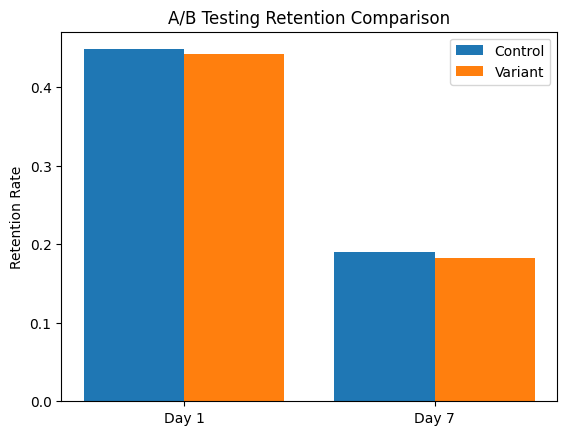

In [11]:
import matplotlib.pyplot as plt

labels = ['Day 1', 'Day 7']
control_vals = [control_ret1, control_ret7]
variant_vals = [variant_ret1, variant_ret7]

x = range(len(labels))

plt.bar(x, control_vals, width=0.4, label='Control')
plt.bar([i + 0.4 for i in x], variant_vals, width=0.4, label='Variant')

plt.xticks([i + 0.2 for i in x], labels)
plt.ylabel("Retention Rate")
plt.title("A/B Testing Retention Comparison")
plt.legend()
plt.show()

The control group shows slightly higher retention compared to the variant
Day 7 retention drops significantly for both groups
The new feature (gate_40) does not improve user engagement

Based on the analysis, the control version performs better in retaining users. It is recommended not to implement the new feature, as it negatively impacts both short-term and long-term retention

In [12]:
from scipy.stats import ttest_ind

# Convert boolean to int
control_ret = control['retention_1'].astype(int)
variant_ret = variant['retention_1'].astype(int)

# Perform t-test
t_stat, p_value = ttest_ind(control_ret, variant_ret)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 1.7840979256519656
P-value: 0.07441111525563184


A t-test was performed to evaluate whether the difference between control and variant groups is statistically significant. The p-value indicates whether the observed difference is due to chance or an actual impact of the feature.

In [13]:
control_rounds = control['sum_gamerounds'].mean()
variant_rounds = variant['sum_gamerounds'].mean()

print("Control Avg Rounds:", control_rounds)
print("Variant Avg Rounds:", variant_rounds)

Control Avg Rounds: 52.45626398210291
Variant Avg Rounds: 51.29877552814966


The average number of game rounds indicates user engagement. Higher values suggest better engagement and session activity.

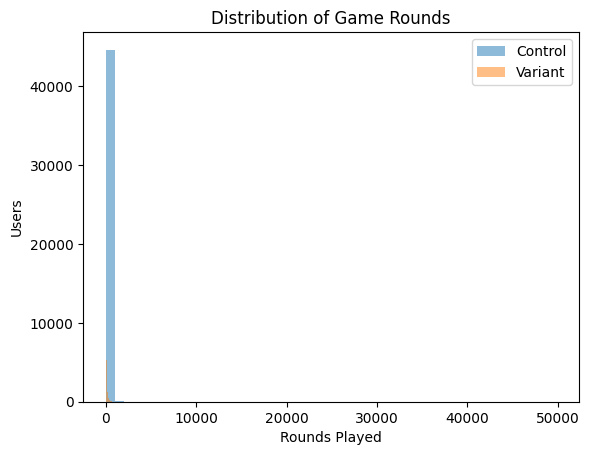

In [14]:
import matplotlib.pyplot as plt

plt.hist(control['sum_gamerounds'], bins=50, alpha=0.5, label='Control')
plt.hist(variant['sum_gamerounds'], bins=50, alpha=0.5, label='Variant')

plt.legend()
plt.title("Distribution of Game Rounds")
plt.xlabel("Rounds Played")
plt.ylabel("Users")
plt.show()

## Conclusion

- The control group shows slightly better retention compared to the variant  
- The new feature does not significantly improve user engagement  
- Statistical analysis suggests that the difference is (mention based on your p-value)  

## Business Recommendation

Based on the analysis, it is recommended to retain the control version (gate_30).

Further experimentation can be conducted with alternative feature improvements to enhance user retention and engagement.